#**Oil Spill**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##**Overview**



###**Load libraries**

In [ ]:
# standard
import os
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pandas import set_option
# sklearn
from sklearn.metrics import confusion_matrix, classification_report
#pd.set_option('display.max_columns',None)



###**Functions**

In [ ]:
def plot_dataframe_structure(dataset):
    plt.figure()
    dataset.dtypes.value_counts().plot.pie(ylabel='', autopct='%1.1f%%')
    plt.title('Data Types')
    plt.show()

In [ ]:
def plot_and_analyze_target_distribution(dataset):
    # Ensure that 'dataset' is a DataFrame and has the expected columns
    if dataset is None or not isinstance(dataset, pd.DataFrame) or dataset.columns[-1] not in dataset:
        print("Invalid DataFrame or column")
        return

    # Create a count plot
    plt.figure(figsize=(8,6))
    sns.countplot(data=dataset, x=dataset.columns[-1], palette=['#9fb8ad', '#475841'])
    plt.xticks([0,1], ['Non-Spill', 'Spill'], fontsize=15)
    plt.show()

    # Analyze the target distribution
    target = dataset.values[:,-1]
    counter = Counter(target)
    for k, v in counter.items():
        class_label = "Spill" if k == 1.0 else "Non-Spill"
        per = v / len(target) * 100
        print(f'Class={k} ({class_label}), Count={v}, Percentage={per:.3f}%')

In [ ]:
def plot_and_analyze_resampled_target_distribution(target):
    # Ensure that 'target' is a Series or a numpy array
    if target is None or not (isinstance(target, pd.Series) or isinstance(target, np.ndarray)):
        print("Invalid target data")
        return

    # Create a DataFrame from the target data for visualization
    target_df = pd.DataFrame(target, columns=['target'])

    # Create a count plot
    plt.figure(figsize=(8,6))
    sns.countplot(data=target_df, x='target', palette=['#9fb8ad', '#475841'])
    plt.xticks([0,1], ['Non-Spill', 'Spill'], fontsize=15)
    plt.show()

    # Analyze the target distribution
    counter = Counter(target)
    for k, v in counter.items():
        class_label = "Spill" if k == 1 else "Non-Spill"
        per = v / len(target) * 100
        print(f'Class={k} ({class_label}), Count={v}, Percentage={per:.3f}%')

In [ ]:
def duplicates(dataset):
    duplicate_rows_dataset = dataset[dataset.duplicated()]
    if duplicate_rows_dataset.shape[0] > 0:
       print('Number of rows before removing:', dataset.count()[0])
       print('Number of duplicate rows:', duplicate_rows_dataset.shape[0])
       dataset = dataset.drop_duplicates()
       print('Number of rows after removing:', dataset.count()[0])
    else:
       print('No duplicate rows.')
    return dataset

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
def find_model_perf(X_train,Y_train,X_test,Y_test):
  model = LogisticRegression()
  model.fit(X_train,Y_train)
  Y_hat = [X[1] for X in model.predict_proba(X_test)]
  auc = roc_auc_score(Y_test, Y_hat)
  return auc

In [ ]:
from sklearn.metrics import accuracy_score
def evaluate_selected_features(X_train, X_test, Y_train, Y_test, selected_feature_names, model):
    """
    Evaluate the accuracy of a given set of selected features.

    Parameters:
    X_train, X_test (DataFrame): Training and testing sets for features.
    Y_train, Y_test (Series): Training and testing sets for the target variable.
    selected_feature_names (list): List of names of the selected features.
    model (sklearn model): The machine learning model to be used for evaluation.

    Returns:
    float: The accuracy of the model with the selected features.
    """
    # Selecting the features by names
    X_train_selected = X_train[selected_feature_names]
    X_test_selected = X_test[selected_feature_names]

    # Training the model
    model.fit(X_train_selected, Y_train)

    # Making predictions and evaluating accuracy
    Y_pred = model.predict(X_test_selected)
    return accuracy_score(Y_test, Y_pred)

In [ ]:
from sklearn.metrics import roc_auc_score

def evaluate_features_auc(rescaledX_res_df, Y_res, selected_feature_names, model):
    # Selecting the features by names
    X_selected = rescaledX_res_df[selected_feature_names]

    # Training the model
    model.fit(X_selected, Y_res)

    # Making predictions
    Y_pred_proba = model.predict_proba(X_selected)[:, 1]

    # Evaluating AUC
    auc_score = roc_auc_score(Y_res, Y_pred_proba)
    return round(auc_score, 5)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_models(models, X_train, X_test, Y_train, Y_test):
    scores = {}
    for name, model in models.items():
        model.fit(X_train, Y_train)
        Y_test_hat = model.predict(X_test)
        scores[name] = {
            'Accuracy': accuracy_score(Y_test, Y_test_hat),
            'Precision': precision_score(Y_test, Y_test_hat, average='weighted'),
            'Recall': recall_score(Y_test, Y_test_hat, average='weighted'),
            'F1-Score': f1_score(Y_test, Y_test_hat, average='weighted')
        }
    return scores

In [ ]:
def get_top_two_models(scores, metric):
    sorted_models = sorted(scores.items(), key=lambda x: x[1][metric], reverse=True)
    return sorted_models[:2]

In [ ]:
def print_metrics(Y_train_hat, Y_test_hat):

    print("Train set accuracy_score: ", accuracy_score(Y_train, Y_train_hat))
    print("Test set accuracy_score: ", accuracy_score(Y_test, Y_test_hat))

    print('-------------------------------------------------------')

    print("Train set performance: \n\n", classification_report(Y_train, Y_train_hat))
    print()
    print("Test set performance: \n\n", classification_report(Y_test, Y_test_hat))

    print('-------------------------------------------------------')

    print("Train set roc_auc_score: ", roc_auc_score(Y_train, pd.Series(Y_train_hat)))
    print("Test set roc_auc_score: ", roc_auc_score(Y_test, pd.Series(Y_test_hat)))

    print('-------------------------------------------------------')

    print("Train set confusion_matrix: \n", confusion_matrix(Y_train, Y_train_hat))
    print()
    print("Test set confusion_matrix: \n", confusion_matrix(Y_test, Y_test_hat))

    print('-------------------------------------------------------')

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score


# Function to update the results with test set results of each model
def update_results_df(model_name, Y_test, Y_test_hat):
    accuracy = accuracy_score(Y_test, Y_test_hat)
    precision, recall, f1_score, _ = precision_recall_fscore_support(Y_test, Y_test_hat, average='binary')
    roc_auc = roc_auc_score(Y_test, Y_test_hat)

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1_score,
        'ROC_AUC_Score': roc_auc
    }

# Initialize an empty list for storing results of all models
results = []

# Function to add or update a model's result in the list
def add_or_update_result(model_name, Y_test, Y_test_hat):
    new_result = update_results_df(model_name, Y_test, Y_test_hat)
    for i, result in enumerate(results):
        if result['Model'] == model_name:
            results[i] = new_result
            break
    else:
        results.append(new_result)

# Function to print updated DataFrame
def print_results_df():
  global results
  results_df = pd.DataFrame(results)
  print(results_df)

def remove_model_from_results(model_name):
    global results
    results = [result for result in results if result['Model'] != model_name]


##**1. Load Data**

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/oil_spill.csv')
display(dataset)


,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
0,1,2558,1506.090,456.630,90,6395000,40.880,7.890,29780.000,0.190,...,2850.000,1000.000,763.160,135.460,3.730,0,33243.190,65.740,7.950,1
1,2,22325,79.110,841.030,180,55812500,51.110,1.210,61900.000,0.020,...,5750.000,11500.000,9593.480,1648.800,0.600,0,51572.040,65.730,6.260,0
2,3,115,1449.850,608.430,88,287500,40.420,7.340,3340.000,0.180,...,1400.000,250.000,150.000,45.130,9.330,1,31692.840,65.810,7.840,1
3,4,1201,1562.530,295.650,66,3002500,42.400,7.970,18030.000,0.190,...,6041.520,761.580,453.210,144.970,13.330,1,37696.210,65.670,8.070,1
4,5,312,950.270,440.860,37,780000,41.430,7.030,3350.000,0.170,...,1320.040,710.630,512.540,109.160,2.580,0,29038.170,65.660,7.350,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,200,12,92.420,364.420,135,97200,59.420,10.340,884.000,0.170,...,381.840,254.560,84.850,146.970,4.500,0,2593.500,65.850,6.390,0
933,201,11,98.820,248.640,159,89100,59.640,10.180,831.000,0.170,...,284.600,180.000,150.000,51.960,1.900,0,4361.250,65.700,6.530,0
934,202,14,25.140,428.860,24,113400,60.140,17.940,847.000,0.300,...,402.490,180.000,180.000,0.000,2.240,0,2153.050,65.910,6.120,0
935,203,10,96.000,451.300,68,81000,59.900,15.010,831.000,0.250,...,402.490,180.000,90.000,73.480,4.470,0,2421.430,65.970,6.320,0


##**2. Initial Data Analysis**

In [ ]:
dataset.head()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
0,1,2558,1506.090,456.630,90,6395000,40.880,7.890,29780.000,0.190,...,2850.000,1000.000,763.160,135.460,3.730,0,33243.190,65.740,7.950,1
1,2,22325,79.110,841.030,180,55812500,51.110,1.210,61900.000,0.020,...,5750.000,11500.000,9593.480,1648.800,0.600,0,51572.040,65.730,6.260,0
2,3,115,1449.850,608.430,88,287500,40.420,7.340,3340.000,0.180,...,1400.000,250.000,150.000,45.130,9.330,1,31692.840,65.810,7.840,1
3,4,1201,1562.530,295.650,66,3002500,42.400,7.970,18030.000,0.190,...,6041.520,761.580,453.210,144.970,13.330,1,37696.210,65.670,8.070,1
4,5,312,950.270,440.860,37,780000,41.430,7.030,3350.000,0.170,...,1320.040,710.630,512.540,109.160,2.580,0,29038.170,65.660,7.350,0


###**Dataset Information**

In [ ]:
#Shape
dataset.shape

(937, 50)

**Data Types**

---

In [ ]:
#Types
types = dataset.dtypes
print(types)

f_1         int64
f_2         int64
f_3       float64
f_4       float64
f_5         int64
f_6         int64
f_7       float64
f_8       float64
f_9       float64
f_10      float64
f_11      float64
f_12      float64
f_13      float64
f_14      float64
f_15      float64
f_16      float64
f_17      float64
f_18      float64
f_19      float64
f_20      float64
f_21      float64
f_22      float64
f_23        int64
f_24      float64
f_25      float64
f_26      float64
f_27      float64
f_28      float64
f_29      float64
f_30      float64
f_31      float64
f_32      float64
f_33      float64
f_34      float64
f_35        int64
f_36        int64
f_37      float64
f_38      float64
f_39        int64
f_40        int64
f_41      float64
f_42      float64
f_43      float64
f_44      float64
f_45      float64
f_46        int64
f_47      float64
f_48      float64
f_49      float64
target      int64
dtype: object


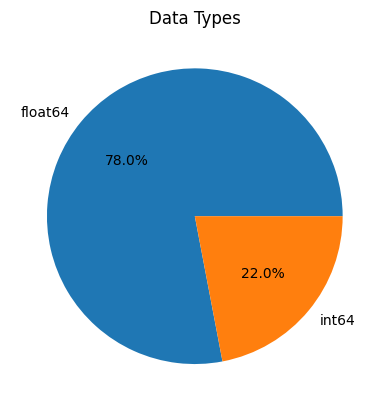

In [ ]:
plot_dataframe_structure(dataset)

**Class Distribution**

---

In [ ]:
print(dataset.groupby(['target']).size())

target
0    896
1     41
dtype: int64


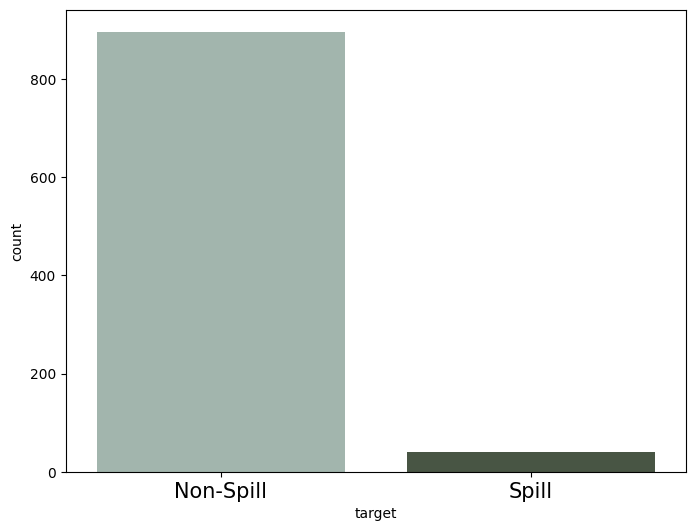

Class=1.0 (Spill), Count=41, Percentage=4.376%
Class=0.0 (Non-Spill), Count=896, Percentage=95.624%


In [ ]:
plot_and_analyze_target_distribution(dataset)

**Descriptive Statistics**

---

In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
dataset.describe()


,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
count,937.000,937.000,937.000,937.000,937.000,937.000,937.000,937.000,937.000,937.000,...,937.000,937.000,937.000,937.000,937.000,937.000,937.000,937.000,937.000,937.000
mean,81.588,332.842,698.707,870.992,84.122,769696.379,43.243,9.128,3940.713,0.221,...,933.929,427.566,255.436,106.113,5.014,0.128,7985.718,61.694,8.120,0.044
std,64.977,1931.939,599.966,522.799,45.362,3831151.032,12.718,3.589,8167.428,0.090,...,1001.681,715.392,534.306,135.618,5.029,0.334,6854.505,10.413,2.909,0.205
min,1.000,10.000,1.920,1.000,0.000,70312.000,21.240,0.830,667.000,0.020,...,0.000,0.000,0.000,0.000,0.000,0.000,2051.500,35.950,5.810,0.000
25%,31.000,20.000,85.270,444.200,54.000,125000.000,33.650,6.750,1371.000,0.160,...,450.000,180.000,90.800,50.120,2.370,0.000,3760.570,65.720,6.340,0.000
50%,64.000,65.000,704.370,761.280,73.000,186300.000,39.970,8.200,2090.000,0.200,...,685.420,270.000,161.650,73.850,3.850,0.000,5509.430,65.930,7.220,0.000
75%,124.000,132.000,1223.480,1260.370,117.000,330468.000,52.420,10.760,3435.000,0.260,...,1053.420,460.980,265.510,125.810,6.320,0.000,9521.930,66.130,7.840,0.000
max,352.000,32389.000,1893.080,2724.570,180.000,71315000.000,82.640,24.690,160740.000,0.740,...,11949.330,11500.000,9593.480,1748.130,76.630,1.000,55128.460,66.450,15.440,1.000


**Correlations Between Attributes**

---

In [ ]:
dataset.corr()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
f_1,1.000,-0.156,0.172,-0.104,-0.017,-0.170,-0.037,-0.205,-0.245,-0.214,...,-0.286,-0.167,-0.157,-0.142,-0.139,-0.164,-0.203,0.294,-0.254,-0.181
f_2,-0.156,1.000,0.058,0.053,-0.037,0.954,-0.137,-0.017,0.830,0.128,...,0.555,0.778,0.801,0.716,-0.081,-0.048,0.119,-0.128,0.139,0.034
f_3,0.172,0.058,1.000,0.550,-0.083,0.051,-0.628,-0.350,0.159,0.074,...,0.187,0.178,0.130,0.177,-0.088,-0.182,-0.022,0.048,0.163,-0.035
f_4,-0.104,0.053,0.550,1.000,0.049,0.025,-0.546,-0.222,0.098,0.202,...,-0.047,0.032,0.022,0.001,-0.220,-0.205,0.107,-0.394,0.476,-0.050
f_5,-0.017,-0.037,-0.083,0.049,1.000,-0.028,0.059,0.124,-0.048,0.099,...,-0.067,-0.015,-0.014,-0.012,-0.077,-0.080,0.070,-0.135,0.117,-0.079
f_6,-0.170,0.954,0.051,0.025,-0.028,1.000,-0.094,-0.001,0.894,0.097,...,0.594,0.845,0.868,0.770,-0.078,-0.047,0.127,-0.059,0.070,0.049
f_7,-0.037,-0.137,-0.628,-0.546,0.059,-0.094,1.000,0.381,-0.188,-0.380,...,-0.115,-0.100,-0.074,-0.074,0.077,0.089,-0.157,0.483,-0.613,-0.026
f_8,-0.205,-0.017,-0.350,-0.222,0.124,-0.001,0.381,1.000,0.001,0.671,...,0.013,-0.016,-0.013,0.002,-0.062,-0.052,-0.028,-0.101,0.034,-0.014
f_9,-0.245,0.830,0.159,0.098,-0.048,0.894,-0.188,0.001,1.000,0.164,...,0.676,0.785,0.770,0.736,-0.073,-0.049,0.103,-0.080,0.113,0.077
f_10,-0.214,0.128,0.074,0.202,0.099,0.097,-0.380,0.671,0.164,1.000,...,0.082,0.053,0.043,0.042,-0.113,-0.096,0.112,-0.587,0.603,-0.013


**Skew of Univariate Distributions**

---
The skew result show a positive (right) or negative (left) skew. Values closer to zero show
less skew.


In [ ]:
skew = dataset.skew()
print(skew)

f_1       1.048
f_2      12.680
f_3       0.252
f_4       0.638
f_5       0.360
f_6      13.039
f_7       0.693
f_8       1.183
f_9      10.257
f_10      1.482
f_11      5.913
f_12      1.265
f_13      1.497
f_14      0.870
f_15      1.524
f_16      0.947
f_17     15.874
f_18     21.513
f_19      1.017
f_20      1.097
f_21      1.505
f_22      1.078
f_23      0.000
f_24      0.286
f_25      1.939
f_26     -0.121
f_27      0.541
f_28      1.450
f_29      5.047
f_30     -0.981
f_31     -1.166
f_32      0.057
f_33     17.616
f_34      0.030
f_35      9.244
f_36      9.544
f_37     -0.102
f_38      5.426
f_39      1.238
f_40      0.412
f_41      4.055
f_42      8.360
f_43     10.407
f_44      6.503
f_45      4.839
f_46      2.230
f_47      2.558
f_48     -2.017
f_49      1.820
target    4.468
dtype: float64


##**3. Exploratory Data Analysis**

###**Univariate Plots**

**Histograms**

---

<ipython-input-62-f16937195ab1>:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  _ = dataset.hist(ax=ax)


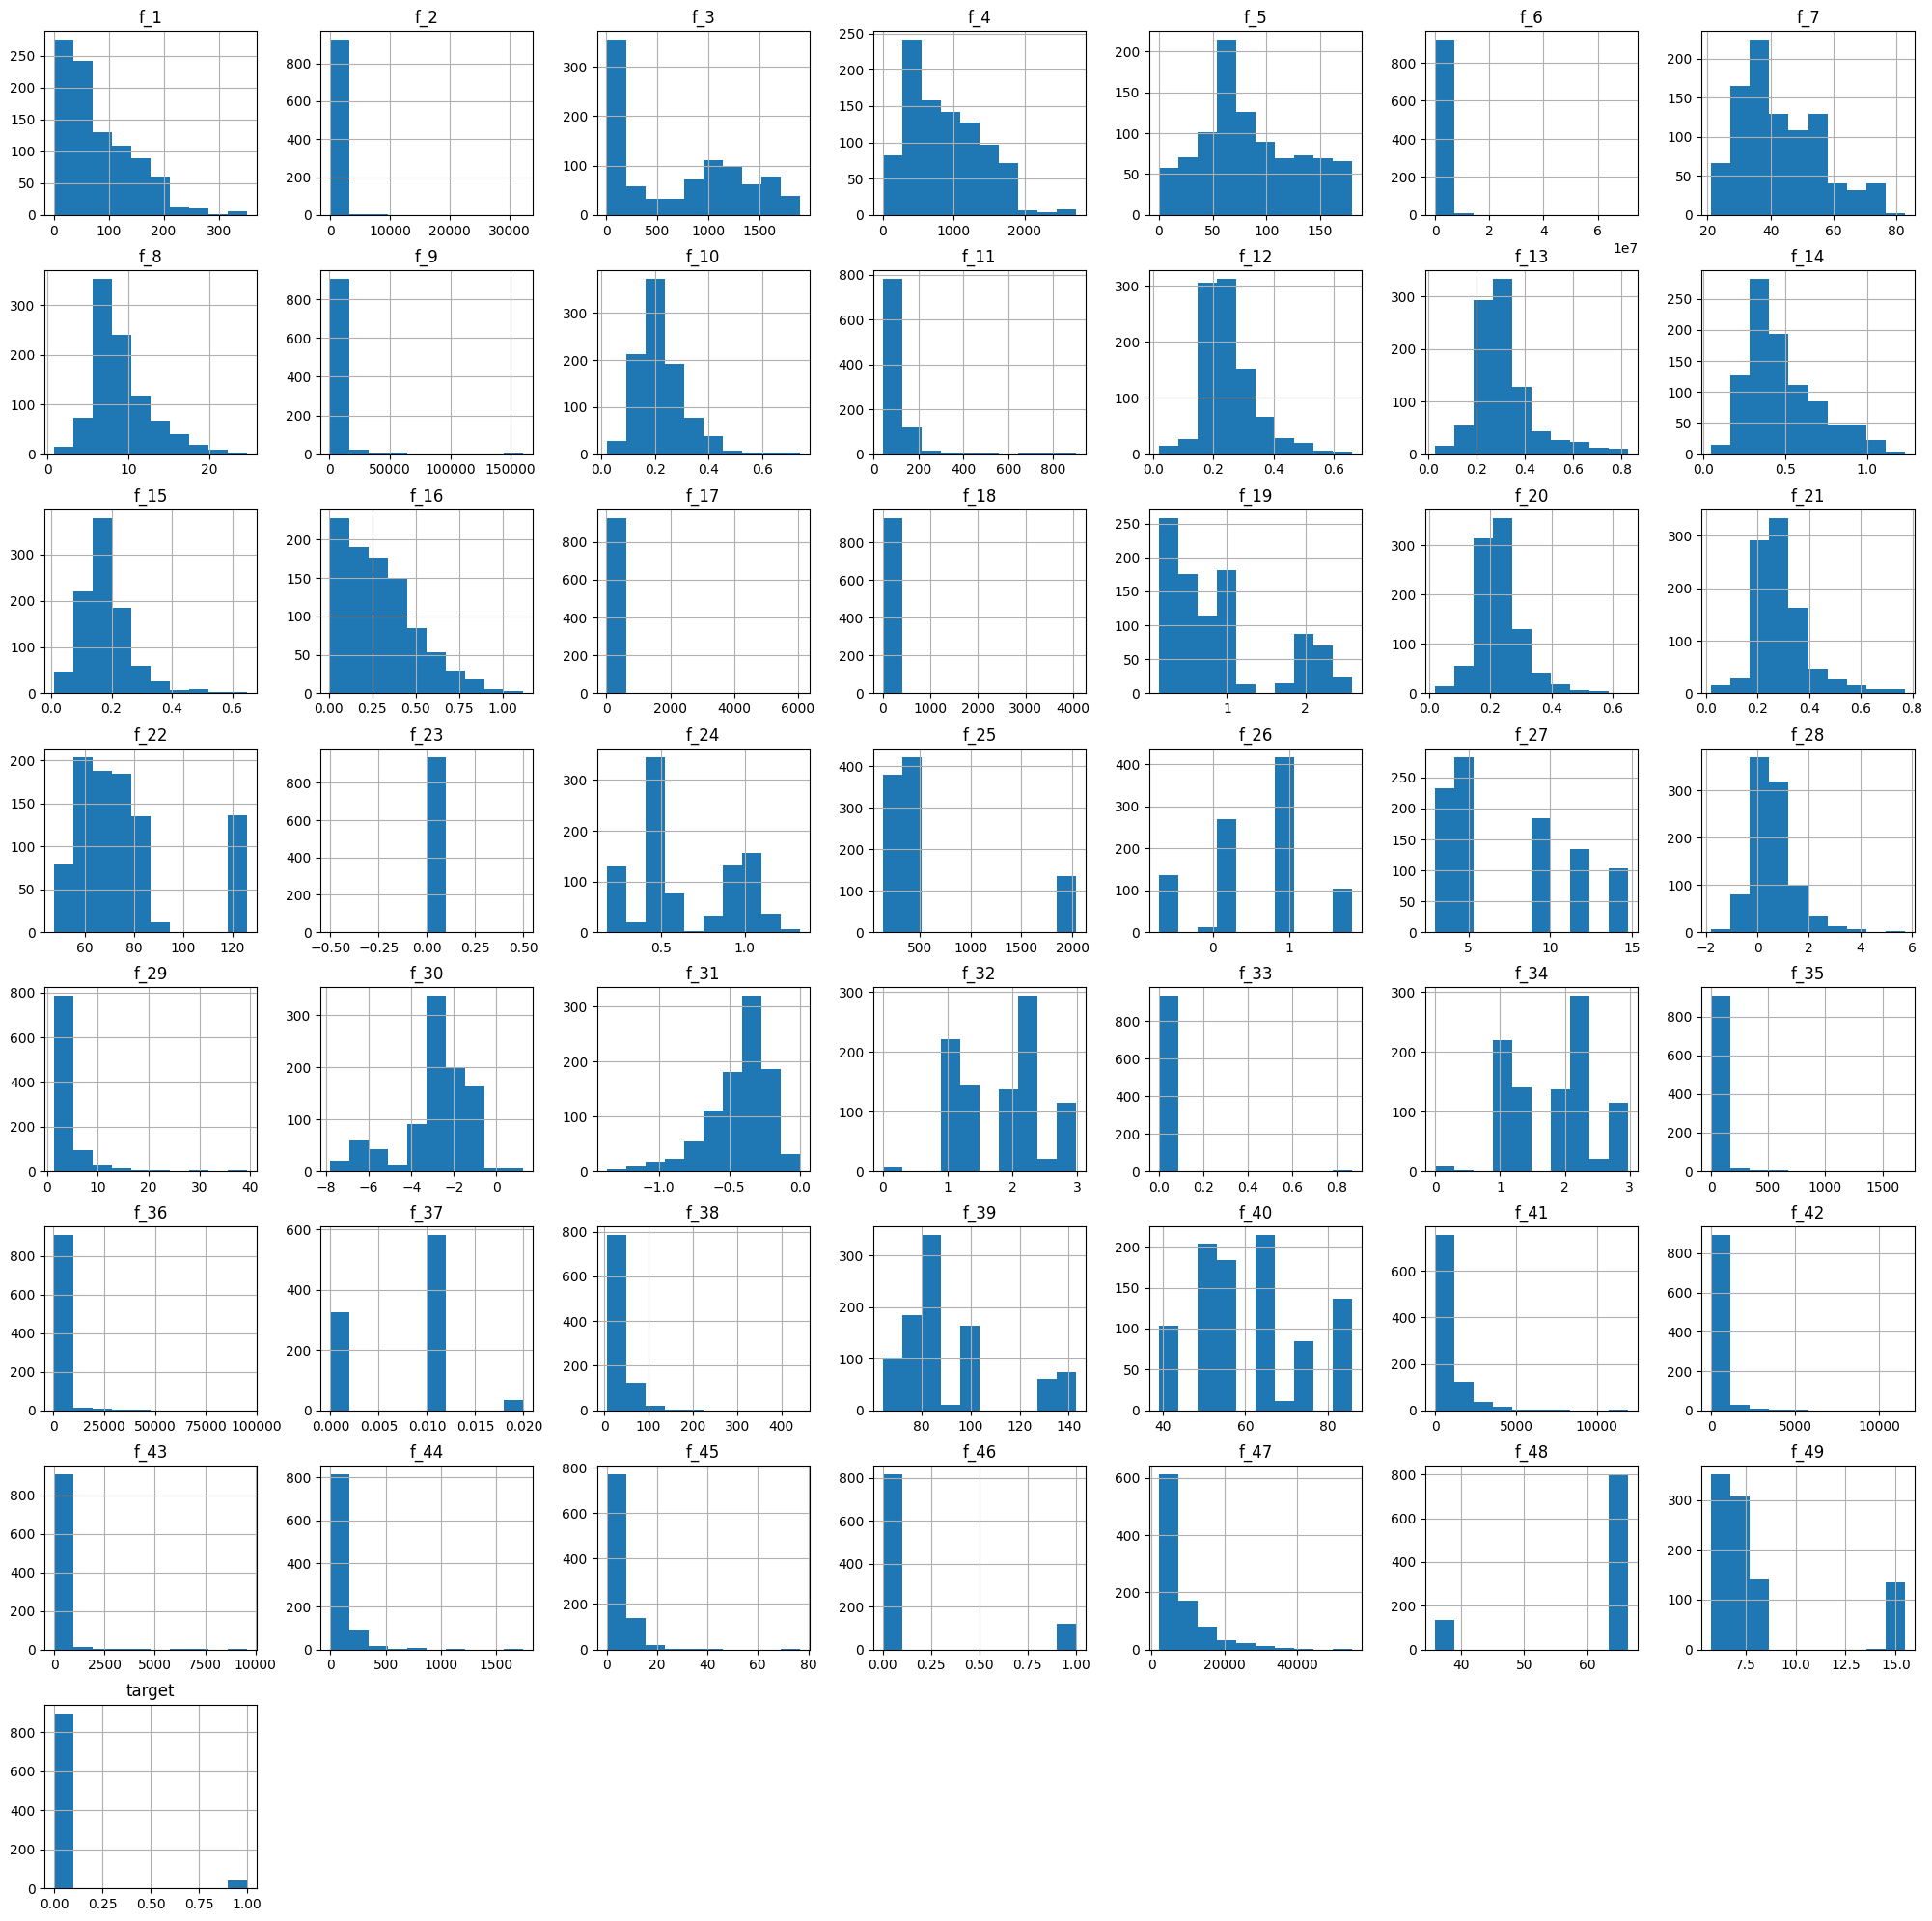

In [ ]:
fig = plt.figure(figsize=(25,25))
ax = fig.gca()

_ = dataset.hist(ax=ax)

###**Multivariate Plots**

**Correlation Matrix**

---

<Axes: >

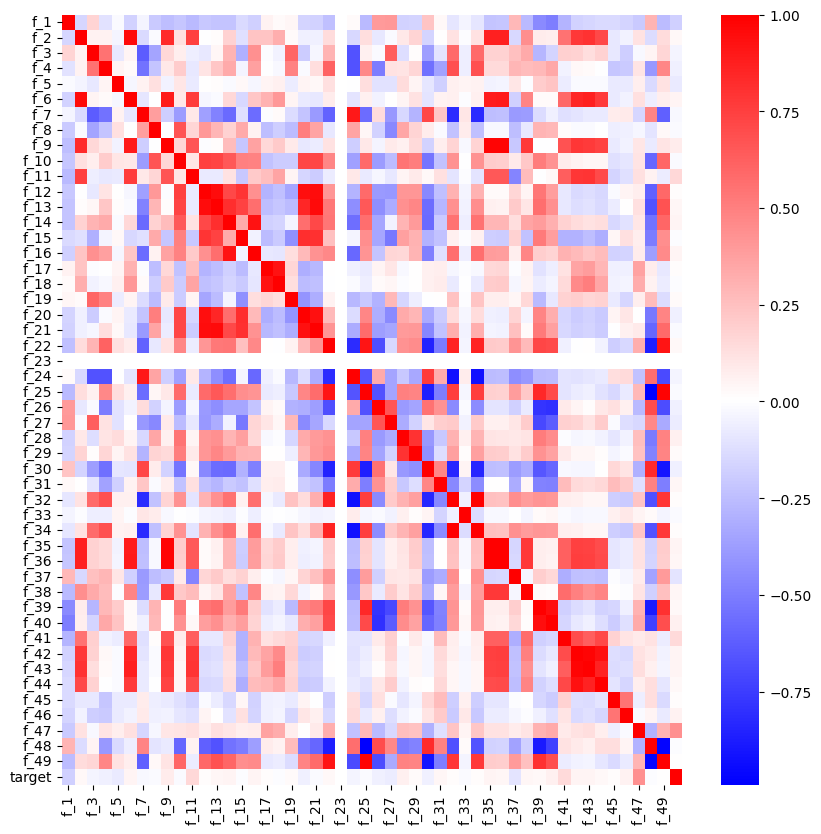

In [ ]:
corr=dataset.corr()
plt.figure(figsize=[10,10])
sns.heatmap(corr,cmap='bwr')

##**4. Preprocess Data**


###**Data Cleaning**

**Check null values**

---

In [ ]:
# Check if there is any null values
dataset.isnull().any()

f_1       False
f_2       False
f_3       False
f_4       False
f_5       False
f_6       False
f_7       False
f_8       False
f_9       False
f_10      False
f_11      False
f_12      False
f_13      False
f_14      False
f_15      False
f_16      False
f_17      False
f_18      False
f_19      False
f_20      False
f_21      False
f_22      False
f_23      False
f_24      False
f_25      False
f_26      False
f_27      False
f_28      False
f_29      False
f_30      False
f_31      False
f_32      False
f_33      False
f_34      False
f_35      False
f_36      False
f_37      False
f_38      False
f_39      False
f_40      False
f_41      False
f_42      False
f_43      False
f_44      False
f_45      False
f_46      False
f_47      False
f_48      False
f_49      False
target    False
dtype: bool

**Check duplicated values**

---

In [ ]:
duplicates(dataset)

No duplicate rows.


,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
0,1,2558,1506.090,456.630,90,6395000,40.880,7.890,29780.000,0.190,...,2850.000,1000.000,763.160,135.460,3.730,0,33243.190,65.740,7.950,1
1,2,22325,79.110,841.030,180,55812500,51.110,1.210,61900.000,0.020,...,5750.000,11500.000,9593.480,1648.800,0.600,0,51572.040,65.730,6.260,0
2,3,115,1449.850,608.430,88,287500,40.420,7.340,3340.000,0.180,...,1400.000,250.000,150.000,45.130,9.330,1,31692.840,65.810,7.840,1
3,4,1201,1562.530,295.650,66,3002500,42.400,7.970,18030.000,0.190,...,6041.520,761.580,453.210,144.970,13.330,1,37696.210,65.670,8.070,1
4,5,312,950.270,440.860,37,780000,41.430,7.030,3350.000,0.170,...,1320.040,710.630,512.540,109.160,2.580,0,29038.170,65.660,7.350,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,200,12,92.420,364.420,135,97200,59.420,10.340,884.000,0.170,...,381.840,254.560,84.850,146.970,4.500,0,2593.500,65.850,6.390,0
933,201,11,98.820,248.640,159,89100,59.640,10.180,831.000,0.170,...,284.600,180.000,150.000,51.960,1.900,0,4361.250,65.700,6.530,0
934,202,14,25.140,428.860,24,113400,60.140,17.940,847.000,0.300,...,402.490,180.000,180.000,0.000,2.240,0,2153.050,65.910,6.120,0
935,203,10,96.000,451.300,68,81000,59.900,15.010,831.000,0.250,...,402.490,180.000,90.000,73.480,4.470,0,2421.430,65.970,6.320,0


**Drop NaN values**

---

From the Correlation table, we see that the f_23 column contains NaN values, so we have decided to drop this column.

In [ ]:
#Check f_23 column
dataset.f_23.value_counts()

0    937
Name: f_23, dtype: int64

In [ ]:
dataset.drop(['f_23'],axis=1,inplace=True)

In [ ]:
display(dataset)

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
0,1,2558,1506.090,456.630,90,6395000,40.880,7.890,29780.000,0.190,...,2850.000,1000.000,763.160,135.460,3.730,0,33243.190,65.740,7.950,1
1,2,22325,79.110,841.030,180,55812500,51.110,1.210,61900.000,0.020,...,5750.000,11500.000,9593.480,1648.800,0.600,0,51572.040,65.730,6.260,0
2,3,115,1449.850,608.430,88,287500,40.420,7.340,3340.000,0.180,...,1400.000,250.000,150.000,45.130,9.330,1,31692.840,65.810,7.840,1
3,4,1201,1562.530,295.650,66,3002500,42.400,7.970,18030.000,0.190,...,6041.520,761.580,453.210,144.970,13.330,1,37696.210,65.670,8.070,1
4,5,312,950.270,440.860,37,780000,41.430,7.030,3350.000,0.170,...,1320.040,710.630,512.540,109.160,2.580,0,29038.170,65.660,7.350,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,200,12,92.420,364.420,135,97200,59.420,10.340,884.000,0.170,...,381.840,254.560,84.850,146.970,4.500,0,2593.500,65.850,6.390,0
933,201,11,98.820,248.640,159,89100,59.640,10.180,831.000,0.170,...,284.600,180.000,150.000,51.960,1.900,0,4361.250,65.700,6.530,0
934,202,14,25.140,428.860,24,113400,60.140,17.940,847.000,0.300,...,402.490,180.000,180.000,0.000,2.240,0,2153.050,65.910,6.120,0
935,203,10,96.000,451.300,68,81000,59.900,15.010,831.000,0.250,...,402.490,180.000,90.000,73.480,4.470,0,2421.430,65.970,6.320,0


###**Handle Imbalanced Data**

Check again where to put this X, Y

In [ ]:
X = dataset.drop(['target'], axis = 1)
Y = dataset['target']

In [ ]:
display(X)

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_40,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49
0,1,2558,1506.090,456.630,90,6395000,40.880,7.890,29780.000,0.190,...,69,2850.000,1000.000,763.160,135.460,3.730,0,33243.190,65.740,7.950
1,2,22325,79.110,841.030,180,55812500,51.110,1.210,61900.000,0.020,...,69,5750.000,11500.000,9593.480,1648.800,0.600,0,51572.040,65.730,6.260
2,3,115,1449.850,608.430,88,287500,40.420,7.340,3340.000,0.180,...,69,1400.000,250.000,150.000,45.130,9.330,1,31692.840,65.810,7.840
3,4,1201,1562.530,295.650,66,3002500,42.400,7.970,18030.000,0.190,...,69,6041.520,761.580,453.210,144.970,13.330,1,37696.210,65.670,8.070
4,5,312,950.270,440.860,37,780000,41.430,7.030,3350.000,0.170,...,69,1320.040,710.630,512.540,109.160,2.580,0,29038.170,65.660,7.350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,200,12,92.420,364.420,135,97200,59.420,10.340,884.000,0.170,...,50,381.840,254.560,84.850,146.970,4.500,0,2593.500,65.850,6.390
933,201,11,98.820,248.640,159,89100,59.640,10.180,831.000,0.170,...,50,284.600,180.000,150.000,51.960,1.900,0,4361.250,65.700,6.530
934,202,14,25.140,428.860,24,113400,60.140,17.940,847.000,0.300,...,50,402.490,180.000,180.000,0.000,2.240,0,2153.050,65.910,6.120
935,203,10,96.000,451.300,68,81000,59.900,15.010,831.000,0.250,...,50,402.490,180.000,90.000,73.480,4.470,0,2421.430,65.970,6.320


In [ ]:
#The dataset is imbalanced so we are gonna do OVER SAMPLING (SMOTE)
from imblearn.combine import SMOTETomek

In [ ]:
smk = SMOTETomek(random_state=42)

In [ ]:
X_res, Y_res = smk.fit_resample(X,Y)

In [ ]:
X_res.shape, Y_res.shape

((1708, 48), (1708,))

In [ ]:
display(X_res)

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_40,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49
0,1,2558,1506.090,456.630,90,6395000,40.880,7.890,29780.000,0.190,...,69,2850.000,1000.000,763.160,135.460,3.730,0,33243.190,65.740,7.950
1,2,22325,79.110,841.030,180,55812500,51.110,1.210,61900.000,0.020,...,69,5750.000,11500.000,9593.480,1648.800,0.600,0,51572.040,65.730,6.260
2,3,115,1449.850,608.430,88,287500,40.420,7.340,3340.000,0.180,...,69,1400.000,250.000,150.000,45.130,9.330,1,31692.840,65.810,7.840
3,4,1201,1562.530,295.650,66,3002500,42.400,7.970,18030.000,0.190,...,69,6041.520,761.580,453.210,144.970,13.330,1,37696.210,65.670,8.070
4,6,54,1438.130,544.910,82,135000,44.670,6.920,1570.000,0.150,...,69,608.280,200.000,150.000,52.220,4.060,0,30967.250,65.770,7.850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1703,1,1752,992.254,389.982,54,6199846,41.446,10.410,26150.538,0.247,...,68,3330.220,1525.916,969.188,279.100,3.496,0,25558.495,65.797,7.636
1704,82,73,766.158,634.786,78,238312,39.551,10.567,2200.585,0.260,...,60,824.168,283.422,180.188,76.773,4.570,0,26076.458,65.955,7.287
1705,6,175,359.841,1005.040,119,740485,45.088,10.962,5477.542,0.241,...,55,1950.927,632.433,384.807,119.143,8.845,0,25863.682,66.041,6.838
1706,129,15,383.178,347.469,82,126988,53.583,11.775,1216.503,0.217,...,50,494.538,283.061,111.408,107.338,4.767,0,14283.104,65.940,7.320


**Data After Handling**

In [ ]:
Y_res.value_counts()

1    854
0    854
Name: target, dtype: int64

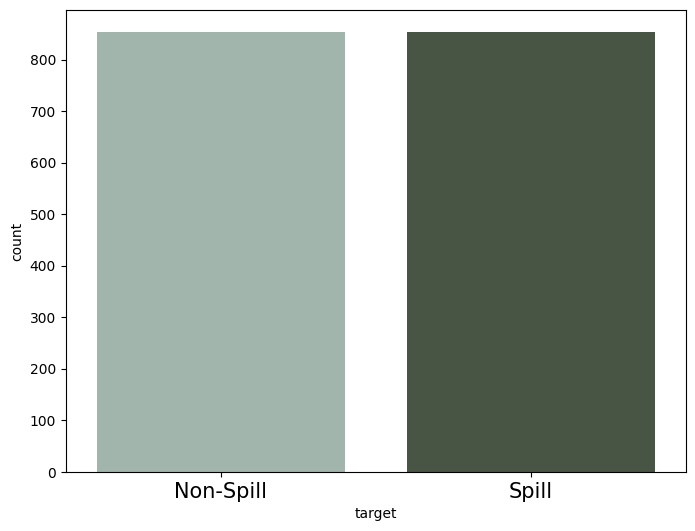

Class=1 (Spill), Count=854, Percentage=50.000%
Class=0 (Non-Spill), Count=854, Percentage=50.000%


In [ ]:
plot_and_analyze_resampled_target_distribution(Y_res)

### **Data Scaling**

**Rescale Data**

---
Rescale data by using the MinMaxScaler class


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from numpy import set_printoptions


In [ ]:
#Rescale data
scaler = MinMaxScaler(feature_range=(0, 1))
rescaledX_res = scaler.fit_transform(X_res)
set_printoptions(precision=3, threshold=5)
print("X_rescaled: ")
print(rescaledX_res[:5])



X_rescaled: 
[[0.    0.079 0.795 ... 0.588 0.977 0.222]
 [0.003 0.689 0.041 ... 0.933 0.976 0.047]
 [0.006 0.003 0.766 ... 0.558 0.979 0.211]
 [0.009 0.037 0.825 ... 0.672 0.974 0.235]
 [0.014 0.001 0.759 ... 0.545 0.978 0.212]]


In [ ]:
rescaledX_res_df = pd.DataFrame(rescaledX_res, columns=X.columns)

# Now use the describe method
rescaledX_res_df.describe()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_40,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49
count,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,...,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000
mean,0.159,0.011,0.344,0.288,0.419,0.013,0.351,0.340,0.026,0.279,...,0.489,0.104,0.042,0.030,0.064,0.071,0.083,0.236,0.856,0.233
std,0.173,0.048,0.271,0.179,0.228,0.045,0.178,0.146,0.047,0.112,...,0.256,0.102,0.056,0.048,0.065,0.056,0.276,0.197,0.303,0.264
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.023,0.001,0.102,0.142,0.261,0.001,0.222,0.236,0.005,0.200,...,0.298,0.043,0.016,0.012,0.030,0.035,0.000,0.058,0.974,0.077
50%,0.100,0.002,0.276,0.227,0.383,0.002,0.328,0.297,0.011,0.271,...,0.511,0.067,0.026,0.019,0.045,0.058,0.000,0.191,0.980,0.156
75%,0.245,0.005,0.565,0.415,0.539,0.006,0.476,0.433,0.022,0.343,...,0.638,0.114,0.048,0.031,0.078,0.097,0.000,0.408,0.985,0.208
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


**Standardize Data**

---
Chuyển đổi giá trị của các biến để có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1.
Standardize data by using the StandardScaler class



In [ ]:
#Standardize train data
scaler = StandardScaler()
standardizedX_res = scaler.fit_transform(X_res)
set_printoptions(threshold=5, precision=3)
print("X_standardized: ")
print(standardizedX_res[:5])


X_standardized: 
[[-9.183e-01  1.393e+00  1.665e+00 ...  1.783e+00  3.972e-01 -4.222e-02]
 [-9.018e-01  1.404e+01 -1.119e+00 ...  3.535e+00  3.961e-01 -7.078e-01]
 [-8.853e-01 -1.698e-01  1.555e+00 ...  1.634e+00  4.047e-01 -8.554e-02]
 [-8.689e-01  5.251e-01  1.775e+00 ...  2.208e+00  3.896e-01  5.044e-03]
 [-8.360e-01 -2.088e-01  1.533e+00 ...  1.565e+00  4.004e-01 -8.161e-02]]


In [ ]:
standardizedX_res_df = pd.DataFrame(standardizedX_res, columns=X.columns)

# Now use the describe method
standardizedX_res_df.describe()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_40,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49
count,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,...,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000,1708.000
mean,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,...,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.918,-0.237,-1.269,-1.611,-1.838,-0.295,-1.971,-2.331,-0.558,-2.489,...,-1.909,-1.013,-0.751,-0.633,-0.973,-1.261,-0.301,-1.200,-2.828,-0.885
25%,-0.787,-0.214,-0.892,-0.818,-0.692,-0.274,-0.723,-0.710,-0.443,-0.703,...,-0.745,-0.596,-0.470,-0.389,-0.519,-0.638,-0.301,-0.903,0.390,-0.594
50%,-0.342,-0.194,-0.250,-0.340,-0.156,-0.243,-0.127,-0.296,-0.331,-0.065,...,0.086,-0.357,-0.289,-0.243,-0.287,-0.226,-0.301,-0.232,0.409,-0.295
75%,0.498,-0.140,0.815,0.713,0.527,-0.152,0.705,0.636,-0.086,0.573,...,0.585,0.100,0.114,0.012,0.228,0.467,-0.301,0.873,0.424,-0.097
max,4.860,20.481,2.420,3.991,2.551,21.972,3.651,4.525,20.762,6.441,...,1.998,8.764,17.188,20.132,14.343,16.488,3.321,3.875,0.474,2.908


###**Feature Selection**

---

Three benefits of performing feature selection
before modeling your data are:
*   **Reduces Overfitting:** Less redundant data means less opportunity to make decisions based on noise.
*   **Improves Accuracy:** Less misleading data means modeling accuracy improves.
*   **Reduces Training Time:** Less data means that algorithms train faster.

**Univariate Selection**

In [ ]:
from sklearn.linear_model import LogisticRegression
evaluation_model = LogisticRegression()

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

# Assuming rescaledX_res is your preprocessed (rescaled) feature data
# and Y_res is your target variable

# Choose the number of important features (k)
k = 30

# Apply chi-squared test for binary variables
selector = SelectKBest(chi2, k=k)

# Fit and transform the training data
X_train_selected = selector.fit_transform(rescaledX_res_df, Y_res)

# Get the indices of the selected features
selected_features = selector.get_support(indices=True)
print(selected_features)

# If rescaledX_res is a DataFrame, you can get the feature names
if isinstance(rescaledX_res_df, pd.DataFrame):
    selected_features_names = rescaledX_res_df.columns[selected_features].tolist()
    print("Selected Features:", selected_features_names)
else:
    # If rescaledX_res is not a DataFrame, you might not have feature names
    print("Selected feature indices:", selected_features)

univariate_auc = evaluate_features_auc(rescaledX_res_df, Y_res, selected_features_names, evaluation_model)

[ 0  1  2 ... 42 44 45]
Selected Features: ['f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_9', 'f_11', 'f_16', 'f_19', 'f_20', 'f_22', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28', 'f_31', 'f_33', 'f_35', 'f_36', 'f_37', 'f_38', 'f_40', 'f_41', 'f_42', 'f_43', 'f_44', 'f_46', 'f_47']


**Recursive Feature Elimination**

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Select the Logistic Regression model
model = LogisticRegression()

# Initialize RFE and select the number of features to keep
rfe = RFE(model, n_features_to_select=30)

# Fit and transform the data
X_selected = rfe.fit_transform(rescaledX_res_df, Y_res)

# Get the indices of the selected features
selected_features = rfe.get_support(indices=True)
print(selected_features)

# Get the names of the selected features
selected_features_names = rescaledX_res_df.columns[selected_features].tolist()
# Print the result
print("Selected Features:", selected_features_names)

# Assuming you have defined evaluate_selected_features_auc
# and have X_test and Y_test datasets for evaluation
rfe_auc = evaluate_features_auc(rescaledX_res_df, Y_res, selected_features_names, evaluation_model)


[ 0  1  2 ... 44 45 46]
Selected Features: ['f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_7', 'f_8', 'f_10', 'f_13', 'f_14', 'f_17', 'f_18', 'f_19', 'f_20', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28', 'f_29', 'f_30', 'f_37', 'f_39', 'f_40', 'f_41', 'f_43', 'f_44', 'f_46', 'f_47', 'f_48']




**Feature Importance**

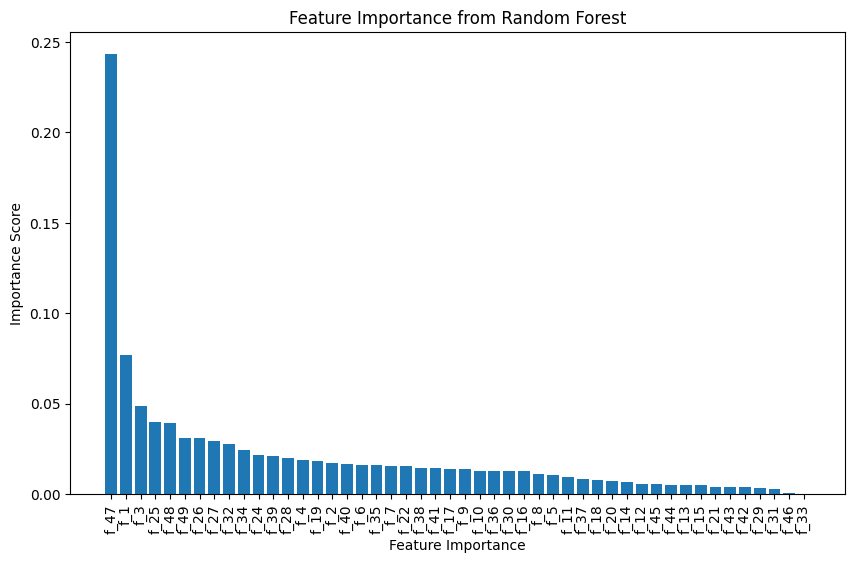

Selected Features: Index(['f_47', 'f_1', 'f_3', 'f_25', 'f_48', 'f_49', 'f_26', 'f_27', 'f_32',
       'f_34', 'f_24', 'f_39', 'f_28', 'f_4', 'f_19', 'f_2', 'f_40', 'f_6',
       'f_35', 'f_7', 'f_22', 'f_38', 'f_41', 'f_17', 'f_9', 'f_10', 'f_36',
       'f_30', 'f_16', 'f_8'],
      dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

# Feature Importance with Random Forest Classifier
model = RandomForestClassifier()

# Train the model on the data
model.fit(rescaledX_res_df, Y_res)

# Get the importance of each feature
importances = model.feature_importances_

# Get the names of each feature
selected_feature_names = rescaledX_res_df.columns

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plot a bar chart to display the importance of each feature
plt.figure(figsize=(10, 6))
plt.bar(range(rescaledX_res_df.shape[1]), importances[indices], align="center")
plt.xticks(range(rescaledX_res_df.shape[1]), selected_feature_names[indices], rotation=90)
plt.xlabel("Feature Importance")
plt.ylabel("Importance Score")
plt.title("Feature Importance from Random Forest")
plt.show()

# Select the number of features you want to retain
k = 30
selected_features = selected_feature_names[indices][:k]
print("Selected Features:", selected_features)

# Assuming you have defined evaluate_selected_features_auc
# and have X_test and Y_test datasets for evaluation
rf_auc = evaluate_features_auc(rescaledX_res_df, Y_res, selected_features_names, evaluation_model)

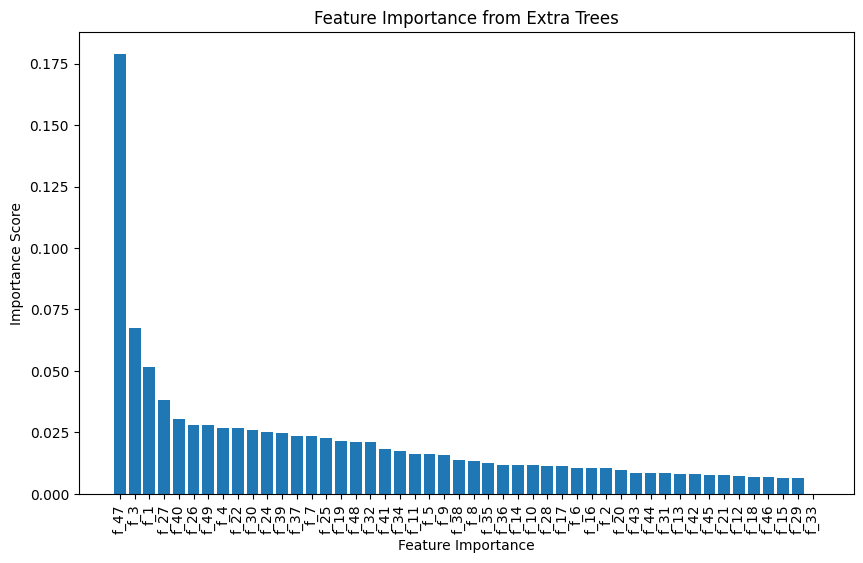

Selected Features: Index(['f_47', 'f_3', 'f_1', 'f_27', 'f_40', 'f_26', 'f_49', 'f_4', 'f_22',
       'f_30', 'f_24', 'f_39', 'f_37', 'f_7', 'f_25', 'f_19', 'f_48', 'f_32',
       'f_41', 'f_34', 'f_11', 'f_5', 'f_9', 'f_38', 'f_8', 'f_35', 'f_36',
       'f_14', 'f_10', 'f_28'],
      dtype='object')


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
import numpy as np
import matplotlib.pyplot as plt

# Feature Importance with ExtraTreesClassifier
model = ExtraTreesClassifier()

# Train the model on the data
model.fit(rescaledX_res_df, Y_res)

# Get the importance of each feature
importances = model.feature_importances_

# Get the names of each feature
selected_feature_names = rescaledX_res_df.columns

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plot a bar chart to display the importance of each feature
plt.figure(figsize=(10, 6))
plt.bar(range(rescaledX_res_df.shape[1]), importances[indices], align="center")
plt.xticks(range(rescaledX_res_df.shape[1]), selected_feature_names[indices], rotation=90)
plt.xlabel("Feature Importance")
plt.ylabel("Importance Score")
plt.title("Feature Importance from Extra Trees")
plt.show()

# Select the number of features you want to retain
k = 30
selected_features = selected_feature_names[indices][:k]
print("Selected Features:", selected_features)

# Assuming you have defined evaluate_selected_features_auc
# and have X_test and Y_test datasets for evaluation
et_auc = evaluate_features_auc(rescaledX_res_df, Y_res, selected_features_names, evaluation_model)


**Simple Method for Choosing the Best Feature Selection**

---

In [ ]:
# Store the accuracies in a dictionary
accuracies = {
    "Univariate Selection": univariate_auc,
    "Recursive Feature Elimination": rfe_auc,
    "Random Forest": rf_auc,
    "Extra Trees": et_auc
}

# Print the accuracies
for method, accuracy in accuracies.items():
    print(f"{method} AUC:", accuracy)

# Find and print the best method
best_method = max(accuracies, key=accuracies.get)
print("\nThe best feature selection method is:", best_method, "with an AUC of:", accuracies[best_method])


Univariate Selection AUC: 0.97864
Recursive Feature Elimination AUC: 0.98223
Random Forest AUC: 0.98223
Extra Trees AUC: 0.98223

The best feature selection method is: Recursive Feature Elimination with an AUC of: 0.98223


**Data After Did Feature Selection (Recursive Feature Elimination)**

---

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Select the Logistic Regression model
model = LogisticRegression()

# Initialize RFE and select the number of features to keep
rfe = RFE(model, n_features_to_select=30)

# Fit and transform the data
X_selected = rfe.fit_transform(rescaledX_res_df, Y_res)

# Get the indices of the selected features
selected_features = rfe.get_support(indices=True)
print(selected_features)

# Get the names of the selected features
selected_features_names = rescaledX_res_df.columns[selected_features].tolist()
# Print the result
print("Selected Features:", selected_features_names)

# Assuming you have defined evaluate_selected_features_auc
# and have X_test and Y_test datasets for evaluation
rfe_auc = evaluate_features_auc(rescaledX_res_df, Y_res, selected_features_names, evaluation_model)

[ 0  1  2 ... 44 45 46]
Selected Features: ['f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_7', 'f_8', 'f_10', 'f_13', 'f_14', 'f_17', 'f_18', 'f_19', 'f_20', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28', 'f_29', 'f_30', 'f_37', 'f_39', 'f_40', 'f_41', 'f_43', 'f_44', 'f_46', 'f_47', 'f_48']


In [ ]:
import pandas as pd

# Creating a new DataFrame with only the selected features
rfe_X = rescaledX_res_df.iloc[:, selected_features]

# If you want to include the column names as well
rfe_X.columns = selected_features_names

# Now, rfe_X is your new dataset with only the features selected by RFE
print("X after feature selection:")
display(rfe_X)

# Y_res remains the same, as feature selection is not applied to target variables
print("Y after feature selection:")
display(Y_res)


X after feature selection:


,f_1,f_2,f_3,f_4,f_5,f_7,f_8,f_10,f_13,f_14,...,f_30,f_37,f_39,f_40,f_41,f_43,f_44,f_46,f_47,f_48
0,0.000,0.079,0.795,0.167,0.500,0.320,0.296,0.243,0.288,0.373,...,0.451,0.000,0.316,0.638,0.239,0.080,0.077,0.000,0.588,0.977
1,0.003,0.689,0.041,0.308,1.000,0.486,0.016,0.000,0.000,0.051,...,0.616,0.000,0.316,0.638,0.481,1.000,0.943,0.000,0.933,0.976
2,0.006,0.003,0.766,0.223,0.489,0.312,0.273,0.229,0.363,0.381,...,0.490,0.500,0.316,0.638,0.117,0.016,0.026,1.000,0.558,0.979
3,0.009,0.037,0.825,0.108,0.367,0.345,0.299,0.243,0.288,0.364,...,0.470,0.000,0.316,0.638,0.506,0.047,0.083,1.000,0.672,0.974
4,0.014,0.001,0.759,0.200,0.456,0.382,0.255,0.186,0.275,0.407,...,0.431,0.500,0.316,0.638,0.051,0.016,0.030,0.000,0.545,0.978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1703,0.000,0.054,0.524,0.143,0.300,0.329,0.401,0.325,0.370,0.429,...,0.444,0.000,0.367,0.617,0.279,0.101,0.160,0.000,0.443,0.979
1704,0.231,0.002,0.404,0.233,0.433,0.298,0.408,0.343,0.412,0.404,...,0.582,0.335,0.266,0.447,0.069,0.019,0.044,0.000,0.453,0.984
1705,0.014,0.005,0.189,0.369,0.661,0.388,0.425,0.316,0.354,0.372,...,0.570,0.000,0.241,0.340,0.163,0.040,0.068,0.000,0.449,0.987
1706,0.365,0.000,0.202,0.127,0.456,0.527,0.459,0.281,0.300,0.218,...,0.593,0.335,0.228,0.234,0.041,0.012,0.061,0.000,0.230,0.983


Y after feature selection:


0       1
1       0
2       1
3       1
4       1
       ..
1703    1
1704    1
1705    1
1706    1
1707    1
Name: target, Length: 1708, dtype: int64

###**Split Data**

In [ ]:
# split the dataset
from sklearn.model_selection import train_test_split

In [ ]:
#Split with random_state = 42, train/test = 70/30
X_train,X_test,Y_train,Y_test = train_test_split(rfe_X, Y_res, test_size = 0.3, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((1195, 30), (513, 30))

##**5. Build classification (or regression) models using the training data**

### **10 classification algorithms**

---

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'LDA': LinearDiscriminantAnalysis(),
    'MLP': MLPClassifier(),  # Increased iterations for convergence
    'Logistic Regression': LogisticRegression()
}

**KNN**

---

In [ ]:
print('KNN:')
print('-------------------------------------------------------')
model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2) #default values
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))

add_or_update_result('KNN', Y_test, model.predict(X_test))

KNN:
-------------------------------------------------------
Train set accuracy_score:  0.9807531380753138
Test set accuracy_score:  0.9649122807017544
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       0.99      0.97      0.98       598
           1       0.97      0.99      0.98       597

    accuracy                           0.98      1195
   macro avg       0.98      0.98      0.98      1195
weighted avg       0.98      0.98      0.98      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.99      0.94      0.96       256
           1       0.94      0.99      0.97       257

    accuracy                           0.96       513
   macro avg       0.97      0.96      0.96       513
weighted avg       0.97      0.96      0.96       513

-------------------------------------------------------
Train set roc_auc_score:  0.98

**Naive Bayes**

---

In [ ]:
print('Naive Bayes:')
print('-------------------------------------------------------')
model = GaussianNB()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))
add_or_update_result('Naive Bayes', Y_test, model.predict(X_test))

Naive Bayes:
-------------------------------------------------------
Train set accuracy_score:  0.799163179916318
Test set accuracy_score:  0.7816764132553606
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       0.90      0.68      0.77       598
           1       0.74      0.92      0.82       597

    accuracy                           0.80      1195
   macro avg       0.82      0.80      0.80      1195
weighted avg       0.82      0.80      0.80      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.89      0.64      0.75       256
           1       0.72      0.92      0.81       257

    accuracy                           0.78       513
   macro avg       0.81      0.78      0.78       513
weighted avg       0.81      0.78      0.78       513

-------------------------------------------------------
Train set roc_auc_score

**SVM**

---

In [ ]:
print('SVM:')
print('-------------------------------------------------------')
model = SVC()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))



add_or_update_result('SVM', Y_test, model.predict(X_test))

SVM:
-------------------------------------------------------
Train set accuracy_score:  0.9807531380753138
Test set accuracy_score:  0.9707602339181286
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       0.98      0.98      0.98       598
           1       0.98      0.98      0.98       597

    accuracy                           0.98      1195
   macro avg       0.98      0.98      0.98      1195
weighted avg       0.98      0.98      0.98      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.97      0.97      0.97       256
           1       0.97      0.97      0.97       257

    accuracy                           0.97       513
   macro avg       0.97      0.97      0.97       513
weighted avg       0.97      0.97      0.97       513

-------------------------------------------------------
Train set roc_auc_score:  0.98

**Decision Tree**

---

In [ ]:
print('Decision Tree:')
print('-------------------------------------------------------')
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))

add_or_update_result('Decision Tree', Y_test, model.predict(X_test))

Decision Tree:
-------------------------------------------------------
Train set accuracy_score:  1.0
Test set accuracy_score:  0.9532163742690059
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       598
           1       1.00      1.00      1.00       597

    accuracy                           1.00      1195
   macro avg       1.00      1.00      1.00      1195
weighted avg       1.00      1.00      1.00      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.96      0.95      0.95       256
           1       0.95      0.96      0.95       257

    accuracy                           0.95       513
   macro avg       0.95      0.95      0.95       513
weighted avg       0.95      0.95      0.95       513

-------------------------------------------------------
Train set roc_auc_score:  1.0
Test 

**Random Forest**

---

In [ ]:
print('Random Forest:')
print('-------------------------------------------------------')

model = RandomForestClassifier()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))

add_or_update_result('Random Forest', Y_test, model.predict(X_test))

Random Forest:
-------------------------------------------------------
Train set accuracy_score:  1.0
Test set accuracy_score:  0.98635477582846
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       598
           1       1.00      1.00      1.00       597

    accuracy                           1.00      1195
   macro avg       1.00      1.00      1.00      1195
weighted avg       1.00      1.00      1.00      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.99      0.98      0.99       256
           1       0.98      0.99      0.99       257

    accuracy                           0.99       513
   macro avg       0.99      0.99      0.99       513
weighted avg       0.99      0.99      0.99       513

-------------------------------------------------------
Train set roc_auc_score:  1.0
Test se

**AdaBoost**

---

In [ ]:
print('AdaBoost:')
print('-------------------------------------------------------')
model = AdaBoostClassifier()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))

add_or_update_result('AdaBoost', Y_test, model.predict(X_test))

AdaBoost:
-------------------------------------------------------
Train set accuracy_score:  1.0
Test set accuracy_score:  0.9785575048732943
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       598
           1       1.00      1.00      1.00       597

    accuracy                           1.00      1195
   macro avg       1.00      1.00      1.00      1195
weighted avg       1.00      1.00      1.00      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.98      0.98      0.98       256
           1       0.98      0.98      0.98       257

    accuracy                           0.98       513
   macro avg       0.98      0.98      0.98       513
weighted avg       0.98      0.98      0.98       513

-------------------------------------------------------
Train set roc_auc_score:  1.0
Test set r

**Gradient Boosting**

---

In [ ]:
print('Gradient Boosting:')
print('-------------------------------------------------------')
model = GradientBoostingClassifier()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))
add_or_update_result('Gradient Boosting', Y_test, model.predict(X_test))

Gradient Boosting:
-------------------------------------------------------
Train set accuracy_score:  1.0
Test set accuracy_score:  0.9727095516569201
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       598
           1       1.00      1.00      1.00       597

    accuracy                           1.00      1195
   macro avg       1.00      1.00      1.00      1195
weighted avg       1.00      1.00      1.00      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.98      0.96      0.97       256
           1       0.97      0.98      0.97       257

    accuracy                           0.97       513
   macro avg       0.97      0.97      0.97       513
weighted avg       0.97      0.97      0.97       513

-------------------------------------------------------
Train set roc_auc_score:  1.0
T

**LDA**

---

In [ ]:
print('LDA:')
print('-------------------------------------------------------')
model = LinearDiscriminantAnalysis()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))
add_or_update_result('LDA', Y_test, model.predict(X_test))

LDA:
-------------------------------------------------------
Train set accuracy_score:  0.9497907949790795
Test set accuracy_score:  0.9376218323586745
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       0.95      0.95      0.95       598
           1       0.95      0.95      0.95       597

    accuracy                           0.95      1195
   macro avg       0.95      0.95      0.95      1195
weighted avg       0.95      0.95      0.95      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.93      0.95      0.94       256
           1       0.94      0.93      0.94       257

    accuracy                           0.94       513
   macro avg       0.94      0.94      0.94       513
weighted avg       0.94      0.94      0.94       513

-------------------------------------------------------
Train set roc_auc_score:  0.94

**MLP**

---

In [ ]:
print('MLP:')
print('-------------------------------------------------------')
model = MLPClassifier()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))
add_or_update_result('MLP', Y_test, model.predict(X_test))

MLP:
-------------------------------------------------------
Train set accuracy_score:  0.9765690376569037
Test set accuracy_score:  0.9746588693957114
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       0.99      0.97      0.98       598
           1       0.97      0.99      0.98       597

    accuracy                           0.98      1195
   macro avg       0.98      0.98      0.98      1195
weighted avg       0.98      0.98      0.98      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.98      0.97      0.97       256
           1       0.97      0.98      0.97       257

    accuracy                           0.97       513
   macro avg       0.97      0.97      0.97       513
weighted avg       0.97      0.97      0.97       513

-------------------------------------------------------
Train set roc_auc_score:  0.97

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
print_results_df()

               Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC_Score
0                KNN     0.965      0.944   0.988     0.966          0.965
1        Naive Bayes     0.782      0.720   0.922     0.809          0.781
2                SVM     0.971      0.969   0.973     0.971          0.971
3      Decision Tree     0.953      0.946   0.961     0.954          0.953
4      Random Forest     0.988      0.988   0.988     0.988          0.988
5           AdaBoost     0.979      0.977   0.981     0.979          0.979
6  Gradient Boosting     0.973      0.966   0.981     0.973          0.973
7                LDA     0.938      0.945   0.930     0.937          0.938
8                MLP     0.975      0.969   0.981     0.975          0.975


**Logistic Regression**

---

In [ ]:
print('Logistic Regression:')
print('-------------------------------------------------------')
model = LogisticRegression()
model.fit(X_train, Y_train)
Y_train_hat = model.predict(X_train)
Y_test_hat = model.predict(X_test)

print_metrics(pd.Series(Y_train_hat), pd.Series(Y_test_hat))
add_or_update_result('Logistic Regression', Y_test, model.predict(X_test))

Logistic Regression:
-------------------------------------------------------
Train set accuracy_score:  0.9414225941422594
Test set accuracy_score:  0.9376218323586745
-------------------------------------------------------
Train set performance: 

               precision    recall  f1-score   support

           0       0.94      0.94      0.94       598
           1       0.94      0.94      0.94       597

    accuracy                           0.94      1195
   macro avg       0.94      0.94      0.94      1195
weighted avg       0.94      0.94      0.94      1195


Test set performance: 

               precision    recall  f1-score   support

           0       0.94      0.93      0.94       256
           1       0.93      0.94      0.94       257

    accuracy                           0.94       513
   macro avg       0.94      0.94      0.94       513
weighted avg       0.94      0.94      0.94       513

-------------------------------------------------------
Train set roc_

In [ ]:
print_results_df()

                 Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC_Score
0                  KNN     0.965      0.944   0.988     0.966          0.965
1          Naive Bayes     0.782      0.720   0.922     0.809          0.781
2                  SVM     0.971      0.969   0.973     0.971          0.971
3        Decision Tree     0.953      0.946   0.961     0.954          0.953
4        Random Forest     0.988      0.988   0.988     0.988          0.988
5             AdaBoost     0.979      0.977   0.981     0.979          0.979
6    Gradient Boosting     0.973      0.966   0.981     0.973          0.973
7                  LDA     0.938      0.945   0.930     0.937          0.938
8                  MLP     0.975      0.969   0.981     0.975          0.975
9  Logistic Regression     0.938      0.934   0.942     0.938          0.938


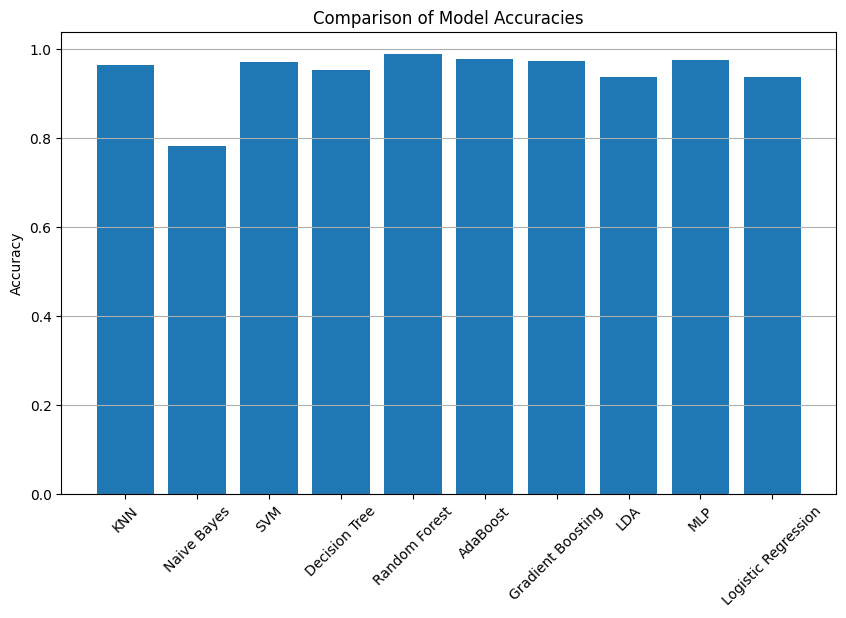

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have your results in a list named 'results'
# Extract the model names and their accuracies
model_names = [result['Model'] for result in results]
accuracies = [result['Accuracy'] for result in results]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies)
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


**After having an overview of 10 algorithms performances, based on the Test set accuracy, we choose the best 2 models**

In [ ]:
# Assuming results_df is your DataFrame containing the results
def find_best_algorithms(df):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC_Score']
    best_algorithms = {}

    for metric in metrics:
        # Sort the DataFrame based on the metric in descending order
        sorted_df = df.sort_values(by=metric, ascending=False)

        # Select the top two algorithms for this metric
        best_algorithms[metric] = sorted_df.iloc[:2]

    return best_algorithms
# Modify print_results_df to return the DataFrame
def get_results_df():
    global results
    return pd.DataFrame(results)

# Get the DataFrame
results_df = get_results_df()

# Get the best algorithms for each metric
best_algorithms = find_best_algorithms(results_df)

In [ ]:
# Print the best algorithms for each metric
for metric, top_algorithms in best_algorithms.items():
    print(f"Top 2 algorithms for {metric}:")
    print(top_algorithms[['Model', metric]], "\n")

Top 2 algorithms for Accuracy:
           Model  Accuracy
4  Random Forest     0.988
5       AdaBoost     0.979 

Top 2 algorithms for Precision:
           Model  Precision
4  Random Forest      0.988
5       AdaBoost      0.977 

Top 2 algorithms for Recall:
           Model  Recall
0            KNN   0.988
4  Random Forest   0.988 

Top 2 algorithms for F1_Score:
           Model  F1_Score
4  Random Forest     0.988
5       AdaBoost     0.979 

Top 2 algorithms for ROC_AUC_Score:
           Model  ROC_AUC_Score
4  Random Forest          0.988
5       AdaBoost          0.979 



**Identifying the Top Two Algorithms Across Key Performance Metrics**

Dựa vào kết quả, có thể thấy một xu hướng nhất quán trong hiệu suất của 2 thuật toán Random Forest và AdaBoost. Hai thuật toán này liên tục xuất hiện, trở thành hai thuật toán hàng đầu trong hầu hết các tiêu chí như Accuracy, Precision, F1-score và ROC-AUC. Điều này cho thấy cả hai thuật toán đều toàn diện, hoạt động hiệu quả trong nhiều khía cạnh của việc phân loại.

Tuy nhiên, trong tiêu chí Recall, KNN ngang hàng với Random Forest, đẩy AdaBoost xuống vị trí thứ ba. Sự khác biệt này phản ánh đặc điểm của từng thuật toán. Random Forest, với phương pháp tổng hợp kết hợp dự đoán từ nhiều cây quyết định, thường mang lại độ chính xác cao và cân bằng tốt giữa Precision và Recall. Trong khi đó, AdaBoost, một thuật toán tăng cường, tập trung vào việc cải thiện độ chính xác bằng cách chú ý đến những trường hợp khó, thường dẫn đến Accuracy và Precision cao, nhưng trong trường hợp này lại kém hơn một chút về Recall so với KNN.

KNN nổi bật trong Recall, thuật toán này có thể rất hiệu quả trong một số trường hợp nhất định, đặc biệt là những trường hợp mà khoảng cách giữa các điểm dữ liệu là một chỉ báo tốt về sự giống nhau của chúng. Tuy nhiên, thuật toán này có thể không đạt hiệu suất cao như các phương pháp tổng hợp trong các tiêu chí khác.

### **Algorithms Tuning**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, KFold

**Use cross-validation on the given datasets to evaluate the models**



In [ ]:
from sklearn.model_selection import cross_val_score
# ensembles
ensembles = []
ensembles.append(('AB', AdaBoostClassifier()))
ensembles.append(('RF', RandomForestClassifier()))
results = []
names = []
for name, model in ensembles:
  kfold = KFold(n_splits=5, random_state=42, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)


AB: 0.977406 (0.008616)
RF: 0.984937 (0.010111)


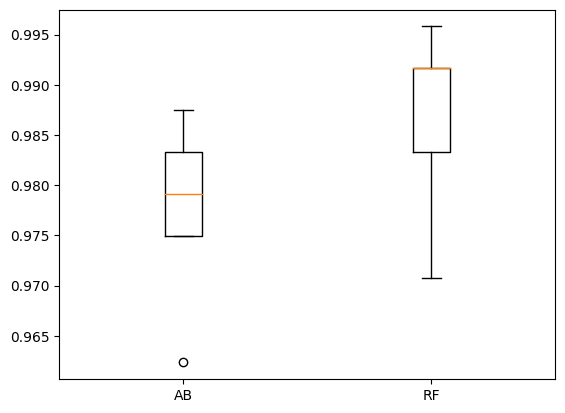

In [ ]:
import matplotlib.pyplot as plt
# Compare Algorithms
fig = plt.figure()

ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

**GridSearchCV for Random Forest**

In [ ]:
num_folds = 5
seed = 42
scoring = 'accuracy'
model = RandomForestClassifier()
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'max_leaf_nodes': [None, 20, 40],
    'random_state': [42]
}
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)
print("Best: %f using %r" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

Best: 0.987448 using {'criterion': 'gini', 'max_depth': 10, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100, 'random_state': 42}


**RandomizedSearchCV for Random Forest**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100,300),
    'max_depth': [None, 10, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': randint(2, 5),
    'min_samples_leaf': [1, 2],
    'max_leaf_nodes': [50, 100, None]
}
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search_result = random_search.fit(X_train, Y_train)
print("Best: %f using %r" % (random_search_result.best_score_, random_search_result.best_params_))


Best: 0.990795 using {'criterion': 'gini', 'max_depth': 10, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 187}


**GridSearchCV for Ada Boost**

In [ ]:
num_folds = 5
seed = 42
scoring = 'accuracy'

# Sử dụng DecisionTreeClassifier(max_depth=1) làm mô hình cơ bản
model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1))

param_grid = {
    'n_estimators': [50],
    'learning_rate': [0.01, 0.1],
    'base_estimator__criterion': ['gini', 'entropy'],
    'algorithm': ['SAMME'],
    'base_estimator__splitter': ['best', 'random'],
    'base_estimator__max_depth': [None, 5],
}

kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)

print("Best: %f using %r" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:674: FutureWarning: Parameter 'base_estimator' of AdaBoostClassifier is deprecated in favor of 'estimator'. See AdaBoostClassifier's docstring for more details.
  estimator = estimator.set_params(**cloned_parameters)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:674: FutureWarning: Parameter 'base_estimator' of AdaBoostClassifier is deprecated in favor of 'estimator'. See AdaBoostClassifier's docstring for more details.
  estimator = estimator.set_params(**cloned_parameters)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:674: FutureWarning: Parameter 'base_estimator' of AdaBoostClassifier is deprecated in favor of 'estimator'. See AdaBoostClassifier's docstring for more details.
  estimator = estimator.set_params(**cloned_parameters)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:674: FutureWarning: Parameter 'ba

Best: 0.981590 using {'algorithm': 'SAMME', 'base_estimator__criterion': 'gini', 'base_estimator__max_depth': 5, 'base_estimator__splitter': 'random', 'learning_rate': 0.1, 'n_estimators': 50}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:905: FutureWarning: Parameter 'base_estimator' of AdaBoostClassifier is deprecated in favor of 'estimator'. See AdaBoostClassifier's docstring for more details.
  clone(base_estimator).set_params(**self.best_params_)


**RandomizedSearchCV for Ada Boost**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(150, 200),
    'learning_rate': uniform(0.01, 0.2),
    'algorithm': ['SAMME'],
    'base_estimator__criterion': ['gini', 'entropy'],
    'base_estimator__splitter': ['best', 'random'],
    'base_estimator__max_depth': [None, 5],
}
random_search = RandomizedSearchCV(
    AdaBoostClassifier(base_estimator=DecisionTreeClassifier()),
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search_result = random_search.fit(X_train, Y_train)
print("Best: %f using %r" % (random_search_result.best_score_, random_search_result.best_params_))


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Best: 0.989958 using {'algorithm': 'SAMME', 'base_estimator__criterion': 'gini', 'base_estimator__max_depth': 5, 'base_estimator__splitter': 'random', 'learning_rate': 0.11495128632644756, 'n_estimators': 193}


**Ensemble using Voting Method**

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
# Định nghĩa các mô hình
ada_model = AdaBoostClassifier()
rf_model = RandomForestClassifier()

# Tạo mô hình Voting
ensemble_model = VotingClassifier(estimators=[('AB', ada_model), ('RF', rf_model)], voting='hard')

# Cross-validation cho mô hình Ensemble
kfold = KFold(n_splits=5, random_state=42, shuffle=True)
cv_results = cross_val_score(ensemble_model, X_train, Y_train, cv=kfold, scoring='accuracy')

# In kết quả
print("Ensemble: %f (%f)" % (cv_results.mean(), cv_results.std()))

Ensemble: 0.984937 (0.010452)


In [ ]:
from sklearn.ensemble import VotingClassifier

models = [
    ('KNN', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)),
    ('Naive Bayes', GaussianNB()),
    ('SVM', SVC()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('LDA', LinearDiscriminantAnalysis()),
    ('MLP', MLPClassifier()),
    ('Logistic Regression', LogisticRegression())
]

ensemble_model = VotingClassifier(estimators=models, voting='hard')
# Cross-validation cho mô hình Ensemble
kfold = KFold(n_splits=5, random_state=42, shuffle=True)
cv_results = cross_val_score(ensemble_model, X_train, Y_train, cv=kfold, scoring='accuracy')

# In kết quả
print("Ensemble: %f (%f)" % (cv_results.mean(), cv_results.std()))

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Ensemble: 0.978243 (0.016183)


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


##**6. Assess model on the test data**

**Final Model: Random Forest**

**Final Classification report**


---

In [ ]:
# prepare the model
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = RandomForestClassifier(
    criterion= 'gini', max_depth= 20, max_leaf_nodes=100, min_samples_leaf= 1, min_samples_split=3, n_estimators= 187
)
model.fit(rescaledX, Y_train)
# estimate accuracy on validation dataset
rescaledValidationX = scaler.transform(X_test)
predictions = model.predict(rescaledValidationX)
print(accuracy_score(Y_test, predictions))
print(confusion_matrix(Y_test, predictions))
print(classification_report(Y_test, predictions))

0.9902534113060428
[[254   2]
 [  3 254]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       256
           1       0.99      0.99      0.99       257

    accuracy                           0.99       513
   macro avg       0.99      0.99      0.99       513
weighted avg       0.99      0.99      0.99       513



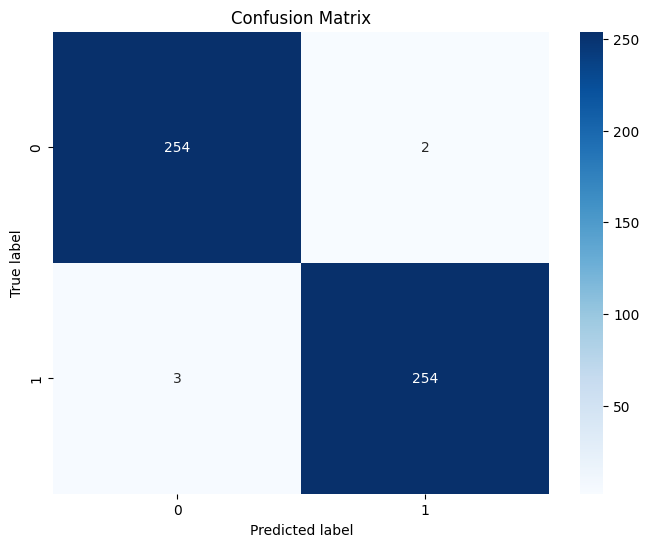

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(Y_test, predictions)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
%%shell
jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/FinalProject_2812.ipynb"


[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/FinalProject_2812.ipynb to html
[NbConvertApp] Writing 1655664 bytes to /content/drive/MyDrive/Colab Notebooks/FinalProject_2812.html
